# NLP: FinBERT Base Model Evaluation & API Testing

This notebook evaluates the performance of a pre-trained **FinBERT** model (`ProsusAI/finbert`) on our custom financial sentiment dataset. Furthermore, it tests the model in a real-world scenario by fetching live financial news via the Alpha Vantage API and comparing FinBERT's predictions against the API's native sentiment scores.

**Key Steps:**
1. **Environment Setup:** Install necessary NLP and Deep Learning libraries.
2. **Data Preparation:** Load, clean, and tokenize the master sentiment dataset.
3. **Base Model Inference:** Run the test set through the pre-trained FinBERT model.
4. **Evaluation:** Calculate Accuracy, F1-Score, ROC-AUC, and plot the Confusion Matrix.
5. **Real-World API Test:** Fetch live news from Alpha Vantage and benchmark FinBERT against third-party sentiment algorithms.
6. **Advanced Metrics:** Compute Expected Calibration Error (ECE) and Pseudo-Perplexity.

In [1]:
# Install required libraries for Transformers, PyTorch, and Data Manipulation
%pip install transformers torch datasets pandas scikit-learn

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ------------------------------- -------- 8.4/10.6 MB 52.1 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 51.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 77.7 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [tokenizers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   --------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\david.suarez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Imports and Configuration

We set up our global variables, including the model identifier from the Hugging Face Hub, and define a consistent seed to ensure our train/test splits and operations remain reproducible.

In [2]:
import os
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
)

# Global Configuration
SEED = 42
MODEL_NAME = "ProsusAI/finbert"
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# Set seeds for reproducibility across NumPy and PyTorch
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

C:\Users\david.suarez\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading & Cleaning

We load the `sentiment_dataset.csv` generated in previous steps. We then perform string normalization, drop missing values, and map our text labels to numerical indices (`0`, `1`, `2`) required by the neural network.

In [ ]:
# Define path and load the dataset
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "sentiment_dataset.csv"))
df = pd.read_csv(DATA_PATH)

print(f"Initial dataset size: {len(df)}")
display(df["source"].value_counts())

# --- Data Cleaning ---
df = df[["text", "sentiment"]].copy()
# Strip whitespace and normalize text
df["text"] = df["text"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

# Drop missing or empty values
df = df.dropna(subset=["text", "sentiment"])
df = df[df["text"] != ""]

# Keep only valid labels
df = df[df["sentiment"].isin(LABEL2ID.keys())]
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)

# Map sentiment strings to numeric indices
df["label"] = df["sentiment"].map(LABEL2ID).astype(int)

print(f"\nTotal clean samples: {len(df):,}")
print(df["sentiment"].value_counts())
display(df.head())

Initial dataset size: 16258


source
twitter    11931
news        4327
Name: count, dtype: int64


Total clean samples: 16,255
sentiment
neutral     10080
positive     3877
negative     2298
Name: count, dtype: int64


,text,sentiment,label
0,"Would Xiamen International Port Co., Ltd (HKG:...",neutral,1
1,Goldman Sachs stock price target raised to $36...,positive,2
2,Nike to record $425 mln charge as it transitio...,negative,0
3,Ocean impact investment fund reaches $92m seco...,neutral,1
4,Last day to sign up for a discount to our comm...,neutral,1


## 3. Tokenization & Data Formatting

Language models cannot process raw text. We must convert our sentences into token IDs using FinBERT's specific tokenizer. We also apply a stratified train/test split, reserving 10% of the data for this base evaluation.

In [5]:
# 1. Stratified Train/Test Split (reserving 10% for evaluation)
_, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df["label"],
)

# 2. Convert Pandas DataFrame to Hugging Face Dataset format
test_ds = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

# 3. Load the pre-trained Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 4. Tokenization Function
def tokenize_batch(batch):
    # Truncate to 128 tokens to speed up inference and avoid memory errors
    return tokenizer(batch["text"], truncation=True, max_length=128)

# Apply tokenization to the dataset
test_tok = test_ds.map(tokenize_batch, batched=True)

# Format the dataset to output PyTorch tensors
cols = ["input_ids", "attention_mask", "label"]
test_tok.set_format(type="torch", columns=cols)

# Initialize a Data Collator to dynamically pad batches to the longest sequence
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

C:\Users\david.suarez\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\david.suarez\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|███████

## 4. Model Loading & Inference Loop

We load the pre-trained `AutoModelForSequenceClassification` from Hugging Face, move it to the GPU (if available), and iterate through our test set to generate predictions without tracking gradients (`torch.no_grad()`).

In [6]:
from torch.utils.data import DataLoader

# Load the base model with specific label mappings
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

# Optional: define metrics computation for Trainer integrations
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# --- Inference Setup ---
model.eval() # Set model to evaluation mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_logits, all_labels = [], []

# Create a DataLoader for batch processing
loader = DataLoader(test_tok, batch_size=32, collate_fn=data_collator)

print(f"Running inference on {device}...")
with torch.no_grad():
    for batch in loader:
        labels_batch = batch.pop("labels").to(device)
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass
        outputs = model(**batch)
        
        # Store results on CPU
        all_logits.append(outputs.logits.cpu())
        all_labels.append(labels_batch.cpu())

# Concatenate batches
all_logits = torch.cat(all_logits).numpy()
all_labels = torch.cat(all_labels).numpy()

# Convert raw logits to probabilities using Softmax
probs = torch.softmax(torch.tensor(all_logits), dim=-1).numpy()
# Extract the final predicted class
preds = probs.argmax(axis=-1)

Loading weights: 100%|██████████| 201/201 [00:00<?, ?it/s]


Running inference on cpu...


In [ ]:
# Inference with expanded dataset
df_expanded = pd.read_csv(os.path.abspath(os.path.join(os.getcwd(), "..", "data", "sentiment_dataset_expanded.csv")))

# Clean and map sentiment to numeric labels
df_expanded["sentiment"] = df_expanded["sentiment"].astype(str).str.strip().str.lower()
df_expanded = df_expanded[df_expanded["sentiment"].isin(LABEL2ID.keys())]
df_expanded["label"] = df_expanded["sentiment"].map(LABEL2ID).astype(int)

# Stratified Train/Test Split (reserving 10% for evaluation)
_, test_expanded_df = train_test_split(
    df_expanded,
    test_size=0.1,
    random_state=SEED,
    stratify=df_expanded["label"],
)

all_logits_expanded, all_labels_expanded = [], []
# Create a Hugging Face Dataset from the test split
expanded_ds = Dataset.from_pandas(test_expanded_df[["text", "label"]].reset_index(drop=True))
# Apply tokenization to the expanded dataset
expanded_tok = expanded_ds.map(tokenize_batch, batched=True)
# Format the expanded dataset to output PyTorch tensors
expanded_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
# Create a DataLoader for the expanded dataset
loader_expanded = DataLoader(expanded_tok, batch_size=32, collate_fn=data_collator)
print(f"Running inference on expanded test set ({len(test_expanded_df)} samples) with {device}...")
with torch.no_grad():
    for batch in loader_expanded:
        labels_batch = batch.pop("labels").to(device)
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass
        outputs = model(**batch)
        
        # Store results on CPU
        all_logits_expanded.append(outputs.logits.cpu())
        all_labels_expanded.append(labels_batch.cpu())
# Concatenate batches for expanded dataset
all_logits_expanded = torch.cat(all_logits_expanded).numpy()
all_labels_expanded = torch.cat(all_labels_expanded).numpy()
# Convert raw logits to probabilities using Softmax for expanded dataset
probs_expanded = torch.softmax(torch.tensor(all_logits_expanded), dim=-1).numpy()
# Extract the final predicted class for expanded dataset
preds_expanded = probs_expanded.argmax(axis=-1)

Map: 100%|██████████| 2766/2766 [00:00<00:00, 20869.10 examples/s]


Running inference on expanded test set (2766 samples) with cpu...


## 5. Base Model Evaluation

We evaluate the out-of-the-box performance of FinBERT on our dataset using standard Classification Metrics, a Confusion Matrix, and the ROC-AUC score (using a One-vs-Rest strategy for multi-class).

CLASSIFICATION REPORT – Base Model
              precision    recall  f1-score   support

    negative     0.0384    0.0609    0.0471       230
     neutral     0.4251    0.1548    0.2269      1008
    positive     0.1152    0.2655    0.1607       388

    accuracy                         0.1679      1626
   macro avg     0.1929    0.1604    0.1449      1626
weighted avg     0.2964    0.1679    0.1857      1626



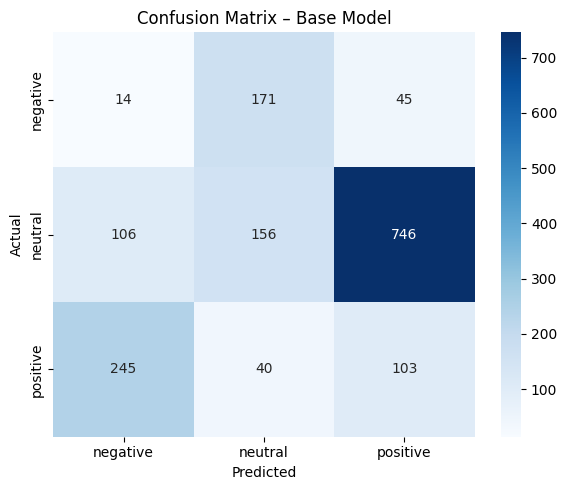


ROC-AUC (weighted OvR): 0.3351


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# --- 1. Classification Report ---
print("=" * 60)
print("CLASSIFICATION REPORT – Base Model")
print("=" * 60)
print(classification_report(all_labels, preds,
      target_names=["negative", "neutral", "positive"], digits=4))

# --- 2. Confusion Matrix ---
cm = confusion_matrix(all_labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title("Confusion Matrix – Base Model")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_base.png", dpi=150)
plt.show()

# --- 3. ROC-AUC Score ---
# Binarize labels for multi-class ROC-AUC
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])
auc = roc_auc_score(labels_bin, probs, multi_class="ovr", average="weighted")
print(f"\nROC-AUC (weighted OvR): {auc:.4f}")

CLASSIFICATION REPORT – Base Model
              precision    recall  f1-score   support

    negative     0.0864    0.0722    0.0786       790
     neutral     0.1559    0.1316    0.1427       988
    positive     0.2956    0.3806    0.3327       988

    accuracy                         0.2035      2766
   macro avg     0.1793    0.1948    0.1847      2766
weighted avg     0.1859    0.2035    0.1923      2766



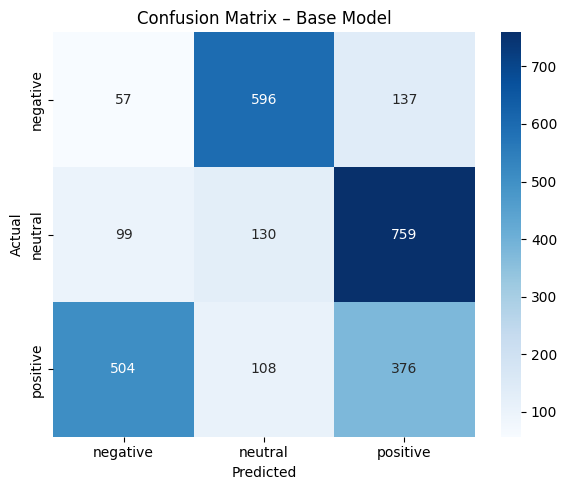


ROC-AUC (weighted OvR): 0.3405


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# --- 1. Classification Report ---
print("=" * 60)
print("CLASSIFICATION REPORT – Base Model")
print("=" * 60)
print(classification_report(all_labels_expanded, preds_expanded,
      target_names=["negative", "neutral", "positive"], digits=4))

# --- 2. Confusion Matrix ---
cm = confusion_matrix(all_labels_expanded, preds_expanded)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title("Confusion Matrix – Base Model")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_base.png", dpi=150)
plt.show()

# --- 3. ROC-AUC Score ---
# Binarize labels for multi-class ROC-AUC
labels_bin = label_binarize(all_labels_expanded, classes=[0, 1, 2])
auc = roc_auc_score(labels_bin, probs_expanded, multi_class="ovr", average="weighted")
print(f"\nROC-AUC (weighted OvR): {auc:.4f}")

## 6. Real-World Application: Alpha Vantage API

To truly test our model, we apply it to live data. We define a list of market tickers, query the Alpha Vantage `NEWS_SENTIMENT` API for the past week's news, and prepare the text for inference.

In [ ]:
from datetime import date
import requests

# Define our expanded universe of assets
expanded_universe = {
    "Equities_US_Broad": ["SPY", "QQQ", "DIA", "IWM"],
    "Equities_Global":   ["EFA", "EEM", "URTH"],
    "Sectors_US":        ["XLF", "XLV", "XLE", "XLK"],
    "Commodities":       ["GLD", "SLV", "USO", "DBA"],
    "Fixed_Income":      ["TLT", "AGG"],
    "Cryptocurrency":    ["BTC-USD", "ETH-USD", "BNB-USD"]
}

TICKERS = [t for group in expanded_universe.values() for t in group]

# API Configuration
ALPHAVANTAGE_KEY = "your_api_key_here"  # Replace with your actual API key
END_DATE   = date.today().isoformat()
START_DATE = (date.today() - pd.Timedelta(weeks=1)).isoformat()
LABELS     = ["negative", "neutral", "positive"]

# Helper to normalize API labels to our format
def normalize_label(label):
    label = label.lower()
    if "positive" in label or "bullish" in label:  return "positive"
    if "negative" in label or "bearish" in label:  return "negative"
    return "neutral"

rows = []
print("Fetching live news from Alpha Vantage...")
for ticker in TICKERS:
    params = {
        "function": "NEWS_SENTIMENT", "tickers": ticker,
        "time_from": START_DATE.replace("-","") + "T0000",
        "time_to":   END_DATE.replace("-","")   + "T2359",
        "limit": 200, "apikey": ALPHAVANTAGE_KEY,
    }
    try:
        # Request data from API
        feed = requests.get("https://www.alphavantage.co/query", params=params, timeout=15).json().get("feed", [])
        for a in feed:
            rows.append({
                "ticker":    ticker,
                "date":      a.get("time_published", "")[:10],
                "title":     a.get("title", ""),
                "text":      f"{a.get('title','')}. {a.get('summary','')}".strip(),
                "url":       a.get("url", ""),
                "av_label":  normalize_label(a.get("overall_sentiment_label", "Neutral")),
                "av_score":  float(a.get("overall_sentiment_score", 0.0) or 0.0),
            })
    except Exception as e:
        print(f"Error {ticker}: {e}")

# Build DataFrame and deduplicate news articles
df_api = pd.DataFrame(rows).drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Downloaded articles: {len(df_api)}")
display(df_api[["ticker","date","title","av_label","av_score","url"]].head())

Fetching live news from Alpha Vantage...
Downloaded articles: 24


,ticker,date,title,av_label,av_score,url
0,SPY,20260517T0,SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY,positive,0.168388,https://www.tradingview.com/symbols/VANTAGE-SP...
1,SPY,20260517T0,SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY,positive,0.243865,https://www.tradingview.com/symbols/VANTAGE-SP...
2,SPY,20260516T1,State Street SPDR S&P 500 ETF Trust Trade Idea...,neutral,-0.023934,https://www.tradingview.com/symbols/EIGHTCAP-S...
3,SPY,20260516T1,SPDR S&P 500 ETF Trust Sees Inflows Amid Tech ...,positive,0.516968,https://www.tipranks.com/news/weekend-updates/...
4,SPY,20260516T0,"SPDR S&P 500 ETF Trust (SPY) Daily Update, 5/1...",neutral,0.038187,https://www.tipranks.com/news/spdr-sp-500-etf-...


## 7. Alpha Vantage vs. FinBERT Comparison

We run the newly fetched API news through FinBERT. We calculate an aggregate `finbert_score` (between -1 and 1) to match the API's scoring methodology. We then compare the results using a Confusion Matrix and Pearson correlation.

,ticker,date,text,av_label,av_score,finbert_label,finbert_score
0,SPY,20260517T0,"SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY. This article compiles several trade ideas and analyses for the SPDR S&P 500 ETF Trust (SPY) from various contributors. It covers market-moving headlines, technical analysis across multiple timeframes, GEX (Gamma Exposure) insights, and potential bullish and bearish scenarios for the upcoming week. The analyses frequently reference economic data, corporate earnings, and geopolitical factors impacting the S&P 500.",positive,0.168,positive,0.911
1,SPY,20260517T0,"SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY. This article compiles several trade ideas and analyses for the SPDR S&P 500 ETF Trust (SPY) from various contributors on TradingView. It covers diverse perspectives ranging from bullish continuation scenarios and long option strategies to warnings of potential double tops, market exhaustion, and even a bearish geopolitical outlook. Key technical levels, economic data, and sentiment indicators are frequently discussed by the contributing analysts.",positive,0.244,positive,0.903
2,SPY,20260516T1,"State Street SPDR S&P 500 ETF Trust Trade Ideas — EIGHTCAP:SPY. This article compiles several trade ideas and analyses for the State Street SPDR S&P 500 ETF Trust (SPY) from various contributors. It covers short-term bullish and bearish scenarios, range trading strategies, support and resistance levels, and broader market themes and economic data influencing SPY. The analyses emphasize identifying market structure, order flow, and managing risk based on technical indicators and price action.",neutral,-0.024,positive,0.910
3,SPY,20260516T1,"SPDR S&P 500 ETF Trust Sees Inflows Amid Tech Strength. The SPDR S&P 500 ETF Trust ($SPY) has seen a 5-day net inflow of $3.59 billion despite a slight weekly dip, driven by strong market sentiment towards its major tech holdings. Nvidia, Apple, and Microsoft are key contributors to this trend, fueled by AI advancements, robust earnings, and strategic corporate decisions. This indicates continued investor confidence in the technology sector's growth potential within the S&P 500.",positive,0.517,negative,-0.929
4,SPY,20260516T0,"SPDR S&P 500 ETF Trust (SPY) Daily Update, 5/15/2026. The SPDR S&P 500 ETF Trust (SPY) declined 1.2% on May 15, impacted by a tech stock pullback, rising oil prices and Treasury yields, and disappointment from the U.S.-China summit. Despite daily losses, SPY experienced $5 billion in net inflows over the past five days. The ETF has a ""Strong Buy"" rating with an implied upside potential of 15.55%, yet hedge fund managers decreased their holdings in the last quarter.",neutral,0.038,neutral,0.004
5,SPY,20260515T1,"Stock Market Live May 15, 2026: S&P 500 (SPY) Deep in the Red. The S&P 500, Dow Jones, and Nasdaq are all trading significantly lower on May 15, 2026, with the S&P 500 and its ETF, SPY, deep in the red. This market pullback is attributed to the lack of major deals from the Trump-Xi meeting and a potential breakdown in the ""unsustainable"" rally of tech stocks. Dell (DELL) is a focus, with analysts expecting strong earnings driven by AI demand, while Cisco (CSCO) posted better-than-expected third-quarter results and increased its AI infrastructure orders guidance.",neutral,0.100,neutral,0.007
6,SPY,20260515T0,SPY ETF Falls 1.2%. The SPY ETF experienced a 1.2% drop. This brief report highlights the recent performance of the popular S&P 500 tracking ETF.,negative,-0.629,neutral,0.010
7,SPY,20260514T2,"Stock Market Today: SPY, QQQ Accelerate to All-Time Highs on ‘Extremely Positive’ Trump-Xi Meeting. U.S. equities, including the S&P 500 ETF (SPY) and Nasdaq 100 ETF (QQQ), reached all-time highs following a ""extremely positive"" meeting between President Trump and Chinese President Xi Jinping. The discussions focused on economic ties, U.S. business access to China, and the war in Iran. Tech stocks, particularly Nvidia (NVDA) and Broadcom

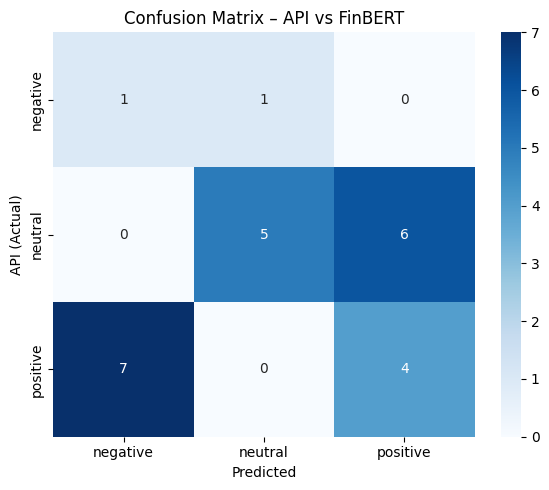

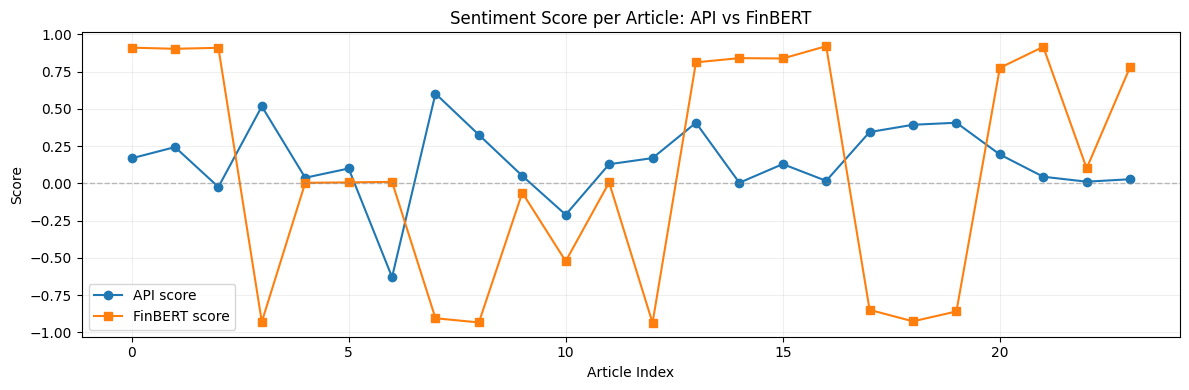


Label Agreement:     41.7%
Pearson Correlation: -0.3662  (p=0.0784)


In [15]:
from scipy.stats import pearsonr

def predict(texts):
    enc = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=128)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
    return probs  # shape (N, 3) — [neg, neu, pos]


# 1. Generate Predictions
api_probs = predict(df_api["text"].tolist())
df_api["finbert_label"] = [LABELS[p.argmax()] for p in api_probs]
df_api["finbert_score"] = (api_probs * np.array([-1, 0, 1])).sum(axis=1)


# 2. Display Comparison (con textos y colores)
pd.set_option("display.max_colwidth", None)

def color_label(val, av_series):
    colors = []
    for i, v in enumerate(val):
        match = v == av_series.iloc[i]
        c = "color: #155724; font-weight: bold" if match else "color: #721c24; font-weight: bold"
        colors.append(c)
    return colors

display(
    df_api[["ticker", "date", "text",
            "av_label", "av_score",
            "finbert_label", "finbert_score"]]
    .head(15)
    .style
    .apply(lambda s: color_label(s, df_api["av_label"]), subset=["finbert_label"])
    .format({"av_score": "{:.3f}", "finbert_score": "{:.3f}"})
    .set_caption("finbert_label en verde si coincide con av_label, rojo si discrepa")
)


# 3. Plot Confusion Matrix
cm_api = confusion_matrix(df_api["av_label"], df_api["finbert_label"], labels=LABELS)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_api, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title("Confusion Matrix – API vs FinBERT")
plt.ylabel("API (Actual)"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_av_vs_finbert.png", dpi=150)
plt.show()


# 4. Plot Score Comparison
plt.figure(figsize=(12, 4))
plt.plot(df_api.index, df_api["av_score"],      marker="o", linewidth=1.5, label="API score")
plt.plot(df_api.index, df_api["finbert_score"], marker="s", linewidth=1.5, label="FinBERT score")
plt.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.5)
plt.title("Sentiment Score per Article: API vs FinBERT")
plt.xlabel("Article Index"); plt.ylabel("Score")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig("score_comparison.png", dpi=150)
plt.show()


# 5. Metrics
agreement = (df_api["av_label"] == df_api["finbert_label"]).mean() * 100
r, p = pearsonr(df_api["av_score"], df_api["finbert_score"])
print(f"\nLabel Agreement:     {agreement:.1f}%")
print(f"Pearson Correlation: {r:.4f}  (p={p:.4f})")

## 8. Advanced Metrics (Calibration & Perplexity)

* **Expected Calibration Error (ECE):** Measures how well the model's predicted probabilities match the true accuracy. A perfectly calibrated model with an ECE of 0 means that when it predicts something with 80% confidence, it is correct 80% of the time.
* **Pseudo-Perplexity:** An exponential of the Cross-Entropy loss. Lower perplexity indicates the model is less "surprised" by the true labels.

In [16]:
import math

# --- 1. Expected Calibration Error (ECE) ---
def compute_ece(probs, labels, n_bins=10):
    confidences = probs.max(axis=-1)
    correct = (probs.argmax(axis=-1) == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if mask.sum() > 0:
            ece += abs(correct[mask].mean() - confidences[mask].mean()) * mask.sum()
    return ece / len(labels)

print(f"ECE (Calibration):      {compute_ece(probs, all_labels):.4f}  (0 = perfect)")

# --- 2. Pseudo-Perplexity ---
loss_fn = torch.nn.CrossEntropyLoss()
ce_loss = loss_fn(torch.tensor(all_logits), torch.tensor(all_labels).long()).item()
ppl = math.exp(ce_loss)

print(f"Pseudo-Perplexity:      {ppl:.4f}")

ECE (Calibration):      0.6647  (0 = perfect)
Pseudo-Perplexity:      17.1734
